# Tienda online Ice

## Paso 1. Abre el archivo de datos y estudia la información general

### Importar librerías

In [1]:
# Importar las librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Estudíando el datasest

In [2]:
# Leer el dataset
games_df = pd.read_csv('/datasets/games.csv')

In [3]:
# Ver información general
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
# Ver una muestra de los datos del DataFrame
print(games_df.head(20))

                                            Name Platform  Year_of_Release  \
0                                     Wii Sports      Wii           2006.0   
1                              Super Mario Bros.      NES           1985.0   
2                                 Mario Kart Wii      Wii           2008.0   
3                              Wii Sports Resort      Wii           2009.0   
4                       Pokemon Red/Pokemon Blue       GB           1996.0   
5                                         Tetris       GB           1989.0   
6                          New Super Mario Bros.       DS           2006.0   
7                                       Wii Play      Wii           2006.0   
8                      New Super Mario Bros. Wii      Wii           2009.0   
9                                      Duck Hunt      NES           1984.0   
10                                    Nintendogs       DS           2005.0   
11                                 Mario Kart DS       DS       

Al imprimir la información general, se observé:
- Nombres de las columnas en mayusculas y minusculas, eso  puede dificultar la manupulación de las columnas.
- Valores ausente en las columnas: "Name", "Year_of_Release", "Genre", "Critic_Score", "User_Score" y "Rating".
- Tipo de datos no adecuados. "Year_of_Release" como float, "Critic_Score" como float y "User_score" se encuentra como object.
- Posibles soluciones en los tipos de dato: "Year_of_Release" a int, "Critic_Score" a int.

## Paso 2. Prepara los datos

### Nombre de columnas

In [5]:
# Remplaza los nombre de las columnas (ponlos en minúsculas)
column_names = games_df.columns.copy()

column_names_low = []
for name in column_names:
    lowered_name = name.lower()
    column_names_low.append(lowered_name)

games_df.columns = column_names_low

print(games_df.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


### Conversión de tipos de datos

In [6]:
# Tratamiento de celdas con TBD
print(games_df['user_score'].isna().sum())
games_df['user_score'] = games_df['user_score'].replace('tbd', np.nan)
print(games_df['user_score'].isna().sum())

games_df['user_score'] = games_df['user_score'].astype(float)

print(f"Columnas user_score: {games_df['critic_score'].dtype}")

6701
9125
Columnas user_score: float64


In [7]:
# Conversión de los datos a los tipos necesarios
games_df['year_of_release'] = games_df['year_of_release'].astype('Int64')

games_df['critic_score'] = games_df['critic_score'].astype('Int64')

print(f"Columna year_of_release: {games_df['year_of_release'].dtype}")
print(f"Columna critic_score: {games_df['critic_score'].dtype}")

Columna year_of_release: Int64
Columna critic_score: Int64


- Se ha cambiado el tipo de dato de la columna "year_of_release" de flaot a entero, devido a que los años se manejan como enteros y no tienen medios.
- Se ha cambiado el tipo de dato de la columna "critic_score", ya que la calificación va de 1 a 100 y no tienen puntos intermedio.
- Se ha convertido a NAN el valor tbd de la columna "user_score".
- También se ha pasado la columna de object a float.

### Valores ausentes

In [8]:
cat_features = [column for column in games_df.columns if games_df[column].dtype=='O']
print(cat_features)

['name', 'platform', 'genre', 'rating']


In [9]:
num_features = [column for column in games_df.columns if games_df[column].dtype!='O']
print(num_features)

['year_of_release', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score']


In [10]:
for feature in cat_features:
    print(f"La variable {feature.upper()} tiene categorias: {games_df[feature].nunique()}\
    \n{games_df[feature].value_counts()}\
    \n \n-----------------------\n")

La variable NAME tiene categorias: 11559    
Need for Speed: Most Wanted                           12
FIFA 14                                                9
Ratatouille                                            9
Madden NFL 07                                          9
LEGO Marvel Super Heroes                               9
                                                      ..
Mobile Suit Gundam version 2.0                         1
Chronicles of Mystery: Curse of the Ancient Temple     1
Donkey Kong GB: Dinky Kong & Dixie Kong                1
Sherlock Holmes: Secret of The Silver Earring          1
Gundam Battle Universe                                 1
Name: name, Length: 11559, dtype: int64    
 
-----------------------

La variable PLATFORM tiene categorias: 31    
PS2     2161
DS      2151
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
GC       556
3DS      520
PSV      430
PS4      392
N64      319
XOne     247
SNE

In [11]:
games_df.isnull().sum().sort_values(ascending=False)

user_score         9125
critic_score       8578
rating             6766
year_of_release     269
name                  2
genre                 2
platform              0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
dtype: int64

In [12]:
games_df.dropna(subset=['name', 'genre'], inplace=True)
games_df.isnull().sum().sort_values(ascending=False)

user_score         9123
critic_score       8576
rating             6764
year_of_release     269
name                  0
platform              0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
dtype: int64

In [13]:
games_df = games_df.fillna({'rating': 'unknown'})
games_df.head(20)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,<NA>,NaN,unknown
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,<NA>,NaN,unknown
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,<NA>,NaN,unknown
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89,8.5,E
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58,6.6,E
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87,8.4,E
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,<NA>,NaN,unknown


In [14]:
# Verificando el porcentaje de valores ausente en las columnas critic_score y user_score.
# Para determinar que hacer con los valores ausentes
games_df[['critic_score', 'user_score']].isna().mean()*100

critic_score    51.313349
user_score      54.586250
dtype: float64

In [15]:
print(games_df.isnull().sum().sort_values(ascending=False))

user_score         9123
critic_score       8576
year_of_release     269
name                  0
platform              0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
rating                0
dtype: int64


**Columna "name" y "genre":**
- Se eliminaron las filas con valores ausentes.
- Se tomo esta desición ya que no eran muchas las filas que tenian valores ausentes en estas columnas.

**Columna "rating":**
- Simplemente se le asigno el valor "unknown".
- Para representar que no tiene una clasificación.

**Columnas "critic_score" y "user_score":**
- Se tomo la desición de dejarlos con valores ausentes.
- Ya que puede significar que el usuario no dejo comentarios e igualmente para el critico.

**Columna "year_of_release":**
- No se realizo operaciones con los valores ausentes de esta columnas.
- Ya que aplicar un método podría alterar el análisis, por que el análisis a realizar se realizara por año.

### Calculas las ventas totales

In [16]:
# Crear una nueva feature, ventas totales
games_df['total_sales'] = games_df['na_sales'] + games_df['eu_sales'] + games_df['jp_sales'] + games_df['other_sales']

print(games_df.head(20))

                                            name platform  year_of_release  \
0                                     Wii Sports      Wii             2006   
1                              Super Mario Bros.      NES             1985   
2                                 Mario Kart Wii      Wii             2008   
3                              Wii Sports Resort      Wii             2009   
4                       Pokemon Red/Pokemon Blue       GB             1996   
5                                         Tetris       GB             1989   
6                          New Super Mario Bros.       DS             2006   
7                                       Wii Play      Wii             2006   
8                      New Super Mario Bros. Wii      Wii             2009   
9                                      Duck Hunt      NES             1984   
10                                    Nintendogs       DS             2005   
11                                 Mario Kart DS       DS       

## Paso 3. Analiza los datos

In [17]:
# Juegos lanzados por año

games_year = games_df.groupby('year_of_release')['name'].count().reset_index()
print(games_year)

    year_of_release  name
0              1980     9
1              1981    46
2              1982    36
3              1983    17
4              1984    14
5              1985    14
6              1986    21
7              1987    16
8              1988    15
9              1989    17
10             1990    16
11             1991    41
12             1992    43
13             1993    60
14             1994   121
15             1995   219
16             1996   263
17             1997   289
18             1998   379
19             1999   338
20             2000   350
21             2001   482
22             2002   829
23             2003   775
24             2004   762
25             2005   939
26             2006  1006
27             2007  1197
28             2008  1427
29             2009  1426
30             2010  1255
31             2011  1136
32             2012   653
33             2013   544
34             2014   581
35             2015   606
36             2016   502


- Antes de 1993 hay muy pocos juegos registrados.
- Después de 1994 el número de juegos aumenta considerablemente.
- Por lo tanto, los datos más representativos están en los años recientes.

### Ventas por plataforma

In [18]:
# Plataformas con mayores ventas totales
games_platform = (
    games_df.groupby('platform')['total_sales']
        .sum()
        .reset_index()
        .sort_values('total_sales', ascending=False)
)

# 20 plataformas con mayores ingresos
games_platform_sales = games_platform[:20] 

print(games_platform_sales)

   platform  total_sales
16      PS2      1255.77
28     X360       971.42
17      PS3       939.65
26      Wii       907.51
4        DS       806.12
15       PS       730.86
6       GBA       317.85
18      PS4       314.14
19      PSP       294.05
13       PC       259.52
2       3DS       259.00
29       XB       257.74
5        GB       255.46
11      NES       251.05
10      N64       218.68
23     SNES       200.04
7        GC       198.93
30     XOne       159.32
0      2600        96.98
27     WiiU        82.19


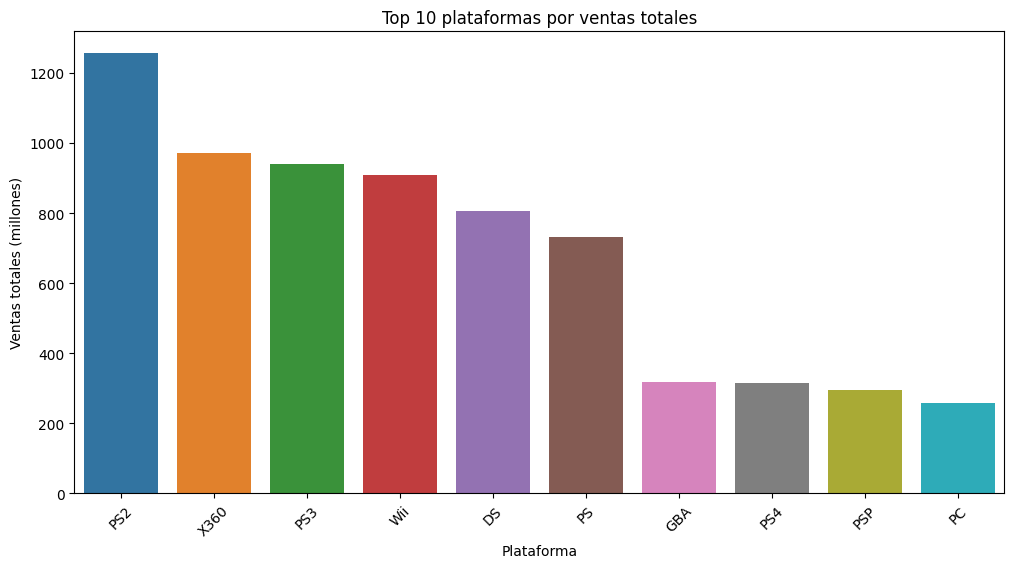

In [19]:
# Crea gráfico de barras para las top 10 plataformas
plt.figure(figsize=(12, 6))
top_10_platforms = games_platform_sales[:10]
sns.barplot(data=top_10_platforms, x='platform', y='total_sales')
plt.title('Top 10 plataformas por ventas totales')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (millones)')
plt.xticks(rotation=45)
plt.show()

In [20]:
# Seleccionar las top 8 plataformas
top_platforms = ['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'GBA', 'PS4']

platform_year_sales = (
    games_df[games_df['platform'].isin(top_platforms)]
    .groupby(['year_of_release', 'platform'])['total_sales']
    .sum()
    .reset_index()
)

print(platform_year_sales.head(10))

   year_of_release platform  total_sales
0             1985       DS         0.02
1             1994       PS         6.03
2             1995       PS        35.96
3             1996       PS        94.70
4             1997       PS       136.17
5             1998       PS       169.49
6             1999       PS       144.53
7             2000      GBA         0.07
8             2000       PS        96.37
9             2000      PS2        39.17


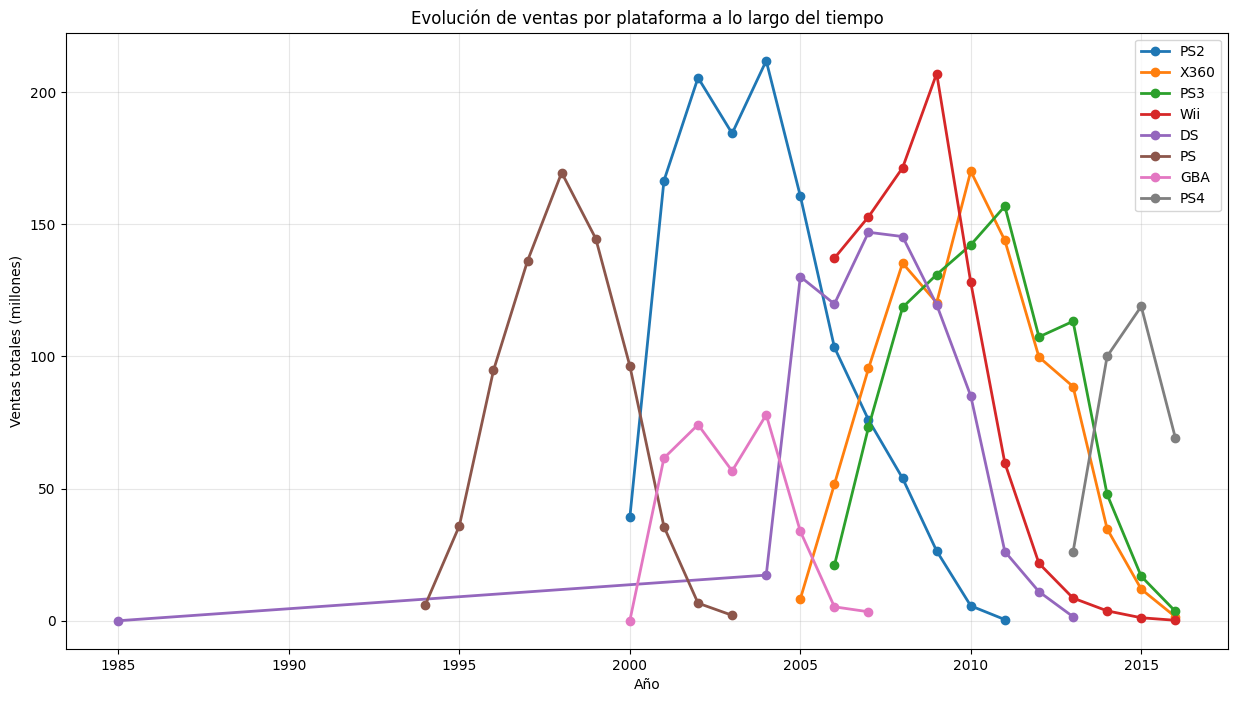

In [21]:
plt.figure(figsize=(15, 8))
for platform in top_platforms:
    data = platform_year_sales[platform_year_sales['platform'] == platform]
    plt.plot(data['year_of_release'], data['total_sales'],
            marker='o', label=platform, linewidth=2)
    
plt.title('Evolución de ventas por plataforma a lo largo del tiempo')
plt.xlabel('Año')
plt.ylabel('Ventas totales (millones)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?
- Las nuevas plataformas tardan entre 11 años en desaparecer.
- Las antiguas en desaparecer tardan entre 22 años en desaparecer.